In [1]:
using Pkg
Pkg.activate(".")
# Pkg.instantiate()

  Activating project at `c:\Users\BMW\Documents\activeInference\rxinfer\axiom_smm`


In [2]:
using RxInfer, Distributions, PyPlot, PGFPlotsX, LaTeXStrings, Random, LinearAlgebra, SpecialFunctions

In [3]:
# load helpers
include("image_utils.jl")
using .ImageUtils

In [66]:
png_path = raw"C:\Users\BMW\Documents\activeInference\rxinfer\axiom_smm\test_image\test_image_26x26px.png"

# 5×N with columns [x,y,r,g,b], x,y∈[-1,1], r,g,b∈[0,1]
data_img = ImageUtils.png_to_data_img(png_path)
data_img[:,10]

5-element Vector{Float32}:
 -1.0
 -0.27999997
  1.0
  1.0
  1.0

### define rules

In [67]:
@rule Categorical(:out, Marginalisation) (m_p::Dirichlet,) = begin
	# # println("Categorical - forward update rule for z with m_p::Dirichlet")
	# # println("  with incoming message(pi), m_p: ", params(m_p)[1])
	# # println("  and with outgoing message (mean(m_p)): ", params(m_p)[1])
    @logscale 0
    return Categorical(mean(m_p))
end

using SpecialFunctions
# Update rule for π (:p) from Categorical factor node towards Dirichlet node
# depends on both m_out (by default) as well as q_out (since we enforce the marginal_dependency on :out -> see functional_dependencies() below for categorical Node)
@rule Categorical(:p, Marginalisation) (m_out::Categorical, q_out::PointMass) = begin
	# println("Categorical - Backward update rule for π. with m_out::Categorical, q_out::PointMass")
	# println("  Cat. node (backward), edge: m_out (outgoing message of z): ", m_out, "Cat. node (backward), edge: q_out (marginal of z): ", q_out)
	@logscale -SpecialFunctions.logfactorial(length(probvec(q_out)))
	# println("Cat. node, new π: ", probvec(q_out) .+ one(eltype(probvec(q_out))))
	return Dirichlet(probvec(q_out) .+ one(eltype(probvec(q_out))))
end

# converts a categorical distribution (soft assignment) into a hard 1-hot vector 
# that represents the delta function δ[cn−ek], as in the paper
# constraint should work on marginal q(z)
function ReactiveMP.constrain_form(
	::PointMassFormConstraint, # anonymous argument (no variable name), double colon :: is a type assertion -> it must be of type PointMassFormConstraint.
	distribution::Categorical # second arguemt is named "distribution", must be of type Categorical
	# e.g. distribution = Categorical([0.1, 0.7, 0.2]) - probabilities over categories
) 
	# println("constrain_form - Categorical distribution (incoming): ", probvec(distribution))
	k = mode(distribution) # Finds the mode (= slot with highest prop representing the most likely category), e.g. k = 2
	v = zeros(length(distribution.support)) # Creates a vector of zeros with the same length as the support of the distribution (number of categories, e.g. 3)
	v[k] = 1 # Sets the value at the index of the most likely category to 1, e.g. v = [0, 1, 0]
	# println("constrain_form - constrained distribution: ", PointMass(v))	
	return PointMass(v) # Returns a PointMass distribution with the vector v, e.g. PointMass([0, 1, 0])
end

struct EnforceMarginalFunctionalDependency <: ReactiveMP.FunctionalDependencies
	edge :: Symbol
end

# called by activate!(factornode, options) - ReactiveMP.jl/nodes/predefined/mixture.jl
# with dependencies = collect_functional_dependencies(factornode, getdependecies(options))
# so "enforce" argument equals getdependencies(options) = EnforceMarginalFunctionalDependency(:switch)
# then activate!(dependencies, factornode, options) is called with activate!(EnforceMarginalFunctionalDependency(:switch), factornode, options)
# so in order to activate the MixtureNode, we need to activate its dependencies (the switch interface)
function ReactiveMP.collect_functional_dependencies(
	::MixtureNode, enforce::EnforceMarginalFunctionalDependency
)
	return enforce
end

# In Categorical node: sets the :out_marginal as extra dependency for the :pi interface. This also allows then to use the :out_marginal in the backward rule for the :p interface of the Categorical Node (see above).
# called in dependencies.jl from activate!(dependencies, FN) -> loop over interfaces of FN -> with_functional_dependencies: 
# message_dependencies, marginal_dependencies = functional_dependencies(strategy, factornode, interface, iindex)
# sets message_(and marginal_)dependencies for given interface of FN 
# in this project it is used for all interfaces of Categorical Node (since we define an EnforceMarginalFunctionalDependency in the model below)
# makes sure :pi interface depends on backward message and marginal of z (:out), while z only depends on :pi_message
function ReactiveMP.functional_dependencies(enforce::EnforceMarginalFunctionalDependency, factornode, interface, iindex)
	# println("functional_dependencies - sets dependencies for the current interface: ", interface, " of factornode: ", functionalform(factornode), ". With enforce: ", enforce)
	# first get default functional dependencies
	message_dependencies, default = functional_dependencies(
		ReactiveMP.collect_functional_dependencies(factornode, nothing), # returns default_functional_dependencies(fform) = DefaultFunctionalDependencies() -> which will make this function_dependencies call trigger the default version defined in dependencies.jl 
		factornode, 
		interface, 
		iindex
	) # default functional_dependencies() is defined in dependencies.jl, returns message_dependencies and marginal_dependencies based on the factorization (stored as LocalFactorNodeClusters)
	# returns 
	# message_dependencies: messages from other interfaces in the same cluster as i (excluding i).
	# marginal_dependencies: local marginals of all other clusters (excluding i’s cluster).

	# set index to the position of the interface that matches enforce.edge
	index = ReactiveMP.findnext(
		i -> ReactiveMP.name(i) === enforce.edge, 
		ReactiveMP.getinterfaces(factornode), 
		1
	)
	# if iindex (index of current interface) equals enforce.edge, return default marginal_dependencies
	if index === iindex 
		# println("    for ", interface, " from ", functionalform(factornode), "|| we set message_dependencies: ", message_dependencies, " || and default marginal_dependencies: ", default)
		return message_dependencies, default
	end
	# println("  adding to default marginal_dependencies: ", default)
	# else add the extra_marginal (enforce.edge) to the marginal_dependencies (here to the pi interface, so that it depends on message AND marginal of z)
	extra_localmarginal = ReactiveMP.FactorNodeLocalMarginal(enforce.edge)
	vmarginal = ReactiveMP.getmarginal(
		ReactiveMP.getvariable(ReactiveMP.getinterfaces(factornode)[index]), ReactiveMP.IncludeAll()
	)
	extra_stream = ReactiveMP.MarginalObservable()
	ReactiveMP.connect!(extra_stream, vmarginal)
	ReactiveMP.setmarginal!(extra_localmarginal, extra_stream)
	
	# Find insertion position (probably might be implemented more efficiently)
	# position should be the index of the current interface: insertafter = count(first(el) < iindex)
	insertafter = sum(first(el) < iindex ? 1 : 0 for el in default; init = 0)
	# final marginal_dependencies has the extra_marginal (enforce.edge) placed at the exact positional slot of the current interface
	marginal_dependencies = ReactiveMP.TupleTools.insertafter(
		default, insertafter, (extra_localmarginal, )
	)

	# Function returns: 
	# - message_dependencies - Which messages does current interface depend on
	# - marginal_dependencies - Which marginals does current interface depend on
	# println("for ", interface, " from ", functionalform(factornode), " message_dependencies: ", message_dependencies, " and marginal_dependencies: ", marginal_dependencies, ". added :out to the default marginal_dependencies: ", default)
	return message_dependencies, marginal_dependencies
end

# only for Mixture Node (for all interfaces :out, :switch, :in[1:nr_components])
# setting the dependencies for the current interface of the Mixture Node manually
function ReactiveMP.functional_dependencies(::EnforceMarginalFunctionalDependency, factornode::MixtureNode{N}, interface, iindex::Int) where {N}
	# println("functional_dependencies for Mixture Node. interface: ", interface, " iindex: ", iindex)
	message_dependencies = if iindex === 1
		# output interface shall depend on: 
		(factornode.inputs,) # (as well as :switch marginal (see below))		
	elseif iindex === 2
		# switch interface shall depend on:
		(factornode.out, factornode.inputs)
	elseif 2 < iindex <= N + 2
		# θk[k]'th input interface shall depend on:
		(factornode.out, ) # (as well as :switch marginal (see below))	
	else
		error("Bad index in functional_dependencies for SwitchNode")
	end

	marginal_dependencies = if iindex === 1
		# output depends on:
		(factornode.switch,)
	elseif iindex == 2
		#  switch depends only on messages, not on marginals
		()
	elseif 2 < iindex <= N + 2
		# θk[k]'th input depends on:
		(factornode.switch,)
	else
		error("Bad index in function_dependencies for MixtureNode")
	end
	# # println(marginal_dependencies)
	return message_dependencies, marginal_dependencies
end

# collect_latest_messages is called in ReactiveMP/dependencies.jl with collect_latest_messages(dependencies, factornode, message_dependencies)
# so messages argument here refers to message_dependencies (computed in functional_dependencies() (see above))
# create an observable/stream that is used to compute the output interface with pipeline constraints
function ReactiveMP.collect_latest_messages(::EnforceMarginalFunctionalDependency, factornode::MixtureNode{N}, messages::Tuple{NTuple{N, ReactiveMP.IndexedNodeInterface}}) where {N}
	inputsinterfaces = messages[1]

	# msgs_names is in the source code of dependencies.jl messagetag
	msgs_names = Val{(ReactiveMP.name(inputsinterfaces[1]), )}()
	msgs_observable =
	combineLatest(map((input) -> ReactiveMP.messagein(input), inputsinterfaces), PushNew()) |>
		map_to((ReactiveMP.ManyOf(map((input) -> ReactiveMP.messagein(input), inputsinterfaces)),))
	# println("collect_latest_messages - for output edge. factornode: ", functionalform(factornode), " with message_dependencies: ", messages[1])
	return msgs_names, msgs_observable
end

# create an observable/stream that is used to compute the switch with pipeline constraints
function ReactiveMP.collect_latest_messages(::EnforceMarginalFunctionalDependency, factornode::MixtureNode{N}, messages::Tuple{ReactiveMP.NodeInterface, NTuple{N, ReactiveMP.IndexedNodeInterface}}) where {N}
	outinterface  = messages[1]
	inputsinterfaces = messages[2]

	msgs_names = Val{(ReactiveMP.name(outinterface), ReactiveMP.name(inputsinterfaces[1]))}()
	msgs_observable =
	combineLatest((ReactiveMP.messagein(outinterface), combineLatest(map((input) -> ReactiveMP.messagein(input), inputsinterfaces), PushNew())), PushNew()) |>
		map_to((ReactiveMP.messagein(outinterface), ReactiveMP.ManyOf(map((input) -> ReactiveMP.messagein(input), inputsinterfaces))))
	# println("collect_latest_messages - factornode: ", functionalform(factornode), " with outinterface: ", outinterface)
	# println("msgs_names: ", msgs_names)
	# println("msgs_observable: ", msgs_observable)
	return msgs_names, msgs_observable
end

# create an observable that is used to compute the input with pipeline constraints
function ReactiveMP.collect_latest_messages(::EnforceMarginalFunctionalDependency, factornode::MixtureNode{N}, messages::Tuple{ReactiveMP.NodeInterface}) where {N}
	outputinterface = messages[1]

	msgs_names = Val{(ReactiveMP.name(outputinterface), )}()
	msgs_observable = combineLatestUpdates((ReactiveMP.messagein(outputinterface), ), PushNew())
	# println("collect_latest_messages - for input edges. factornode: ", functionalform(factornode), " with outputinterface: ", outputinterface)
	return msgs_names, msgs_observable
end

# create an observable that is used to compute the outgoing messages on :out and :in interfaces with pipeline constraints
function ReactiveMP.collect_latest_marginals(::EnforceMarginalFunctionalDependency, factornode::MixtureNode{N}, marginals::Tuple{ReactiveMP.NodeInterface}) where {N}
	switchinterface = marginals[1]

	marginal_names       = Val{(ReactiveMP.name(switchinterface), )}()
	marginals_observable = combineLatestUpdates((getmarginal(ReactiveMP.getvariable(switchinterface), IncludeAll()), ), PushNew())
	# println("collect_latest_marginals - factornode: ", functionalform(factornode), " with marginals: ", marginals)
	return marginal_names, marginals_observable
end

############# 
# NormalMixtureNode
function ReactiveMP.collect_functional_dependencies(
	::NormalMixtureNode{N}, enforce::EnforceMarginalFunctionalDependency
) where {N}
	# println("collect_functional_dependencies - NormalMixtureNode")
	return enforce
end

# NormalMixtureNode
# called during loop over interfaces of NormalMixtureNode
function ReactiveMP.functional_dependencies(::EnforceMarginalFunctionalDependency, factornode::NormalMixtureNode{N}, interface, iindex::Int) where {N}
    # println("functional_dependencies - NormalMixtureNode with interface: ", interface, " and iindex: ", iindex)
	# Message dependencies
    message_dependencies = if iindex === 1
        # out depends on parameters' messages (means, precs)
        (factornode.means, factornode.precs)
    elseif iindex === 2
        # switch depends on out and parameters' messages
        (factornode.out, factornode.means, factornode.precs)
    elseif 2 < iindex <= N + 2
        # mean_k depends on out message and precisions
        (factornode.out,factornode.precs[iindex - 2])
    elseif N + 2 < iindex <= 2N + 2
        # prec_k depends on out message
        (factornode.out,factornode.means[iindex - N - 2])
    else
        error("Bad index in functional_dependencies for NormalMixtureNode")
    end

    # Marginal dependencies
    marginal_dependencies = if iindex === 1
        (factornode.switch,)
    elseif iindex === 2
        ()
    elseif 2 < iindex <= N + 2
        (factornode.switch, )
    elseif N + 2 < iindex <= 2N + 2
        (factornode.switch, )
    else
        error("Bad index in functional_dependencies for NormalMixtureNode")
    end
    return message_dependencies, marginal_dependencies
end

# NormalMixtureNode
# collect_latest_messages creates an observable/stream flowing into the output interface based on incoming  message dependencies (e.g. mean and precision messages for output interface)
# create an observable/stream flowing into the output interface based on incoming means and precision messages
function ReactiveMP.collect_latest_messages(::EnforceMarginalFunctionalDependency, factornode::NormalMixtureNode{N}, message_dependencies::Tuple{NTuple{N, ReactiveMP.IndexedNodeInterface}, NTuple{N, ReactiveMP.IndexedNodeInterface}}) where {N}
	# println("collect_latest_messages NormalMixtureNode - for output edge. factornode: ")
	# println("    ", functionalform(factornode), "with message names: ", ReactiveMP.name(message_dependencies[1][1]), " with message_dependencies: ", message_dependencies[1])
	input_mean_interfaces = message_dependencies[1]
	input_prec_interfaces = message_dependencies[2]

	# msgs_names is in the source code of dependencies.jl messagetag
	msgs_names = Val{(ReactiveMP.name(input_mean_interfaces[1]), ReactiveMP.name(input_prec_interfaces[1]) )}()
	# println("    msgs_names: ", msgs_names)

	# Inner groups: combineLatest over each subgroup (means, precs)
	# messagein converts "handles" (interfaces) into actual message streams
	# map(input -> ReactiveMP.messagein(input), group) turns a group of interfaces (means/precs) into a group of message streams for combineLatest to consume
	mean_streams = map(input -> ReactiveMP.messagein(input), input_mean_interfaces)
	prec_streams = map(input -> ReactiveMP.messagein(input), input_prec_interfaces)

	# combineLatest → emits tuples of latest values.
	# produce emissions when their groups update (values),
	# PushNew() is a Rocket operator that emits a new tuple when any of the input streams emit a new value
	means_obs = combineLatest(mean_streams, PushNew())
	precs_obs = combineLatest(prec_streams, PushNew())

	# Outer sync: both groups must update to produce a new tuple
	# map_to (a Rocket operator) formats the output of combineLatest into a tuple of the correct types
	# we reuse the same streams inside map_to to emit ManyOf(...) built from observables, not value
	# we replace the emitted values with a stable payload that references the streams, which is what the message mapping expects for grouped inputs.
	msgs_observable = combineLatest((means_obs, precs_obs), PushNew()) |>
		map_to((
			# ManyOf(streams) is a stable descriptor of the group:
			# It refers to the underlying message streams, not their current emissions.
			# The message mapping and the rule can subscribe/iterate consistently, align components, and react to future updates without being re-wired.
			ReactiveMP.ManyOf(mean_streams), 
			ReactiveMP.ManyOf(prec_streams)
			))
	
	# println("    after msgs_observable")
	return msgs_names, msgs_observable
end

# NormalMixtureNode
# create an observable/stream flowing into the switch interface based on incoming obs (:out), means and precision messages
function ReactiveMP.collect_latest_messages(::EnforceMarginalFunctionalDependency, factornode::NormalMixtureNode{N}, message_dependencies::Tuple{ReactiveMP.NodeInterface, NTuple{N, ReactiveMP.IndexedNodeInterface}, NTuple{N, ReactiveMP.IndexedNodeInterface}}) where {N}
	# println("collect_latest_messages - factornode: ", functionalform(factornode), " with outinterface: ", message_dependencies[1])

	outputinterface  = message_dependencies[1]
	input_mean_interfaces = message_dependencies[2]
	input_prec_interfaces = message_dependencies[3]

	msgs_names = Val{(ReactiveMP.name(outputinterface), ReactiveMP.name(input_mean_interfaces[1]), ReactiveMP.name(input_prec_interfaces[1]))}()
	# println("    msgs_names: ", msgs_names)

	# Inner groups:
	mean_streams = map(input -> ReactiveMP.messagein(input), input_mean_interfaces)
	prec_streams = map(input -> ReactiveMP.messagein(input), input_prec_interfaces)

	# combineLatest → emits tuples of latest values.
	means_obs = combineLatest(mean_streams, PushNew())
	precs_obs = combineLatest(prec_streams, PushNew())

	# Outer sync: both groups must update to produce a new tuple
	# map_to (a Rocket operator) formats the output of combineLatest into a tuple of the correct types
	msgs_observable = combineLatest((ReactiveMP.messagein(outputinterface), means_obs, precs_obs), PushNew()) |>
		map_to((
			ReactiveMP.messagein(outputinterface),
			ReactiveMP.ManyOf(mean_streams), 
			ReactiveMP.ManyOf(prec_streams)
			))

	# println("   msgs_observable: ", msgs_observable)
	return msgs_names, msgs_observable
end

# NormalMixtureNode
# for Means in case functional_dependencies sets up for  precisions from ALL clusters
# create an observable/stream flowing into MEANS interface based on incoming obs (:out) and precision messages
function ReactiveMP.collect_latest_messages(::EnforceMarginalFunctionalDependency, factornode::NormalMixtureNode{N}, messages::Tuple{ReactiveMP.NodeInterface, NTuple{N, ReactiveMP.IndexedNodeInterface}}) where {N}
	# println("collect_latest_messages - for input edges. factornode: ", functionalform(factornode), " with outputinterface: ", messages[1])

	outputinterface = messages[1]
	input_prec_interfaces = messages[2]

	msgs_names = Val{(ReactiveMP.name(outputinterface), ReactiveMP.name(input_prec_interfaces[1]))}()
	
	# Inner group
	prec_streams = map(input -> ReactiveMP.messagein(input), input_prec_interfaces)

	# combineLatest → emits tuples of latest values.
	precs_obs = combineLatest(prec_streams, PushNew())

	# Outer sync: both groups must update to produce a new tuple
	# map_to (a Rocket operator) formats the output of combineLatest into a tuple of the correct types
	msgs_observable = combineLatest((ReactiveMP.messagein(outputinterface), precs_obs), PushNew()) |>
		map_to((
			ReactiveMP.messagein(outputinterface),
			ReactiveMP.ManyOf(prec_streams)
			))
	# println("    msgs_names: ", msgs_names)
	# println("    msgs_observable: ", msgs_observable)
	return msgs_names, msgs_observable
end

# NormalMixtureNode
# for Means in case functional_dependencies sets up ONLY for  precisions from Current cluster of given mean index
# create an observable/stream flowing into MEANS interface based on incoming obs (:out) and precision messages
function ReactiveMP.collect_latest_messages(::EnforceMarginalFunctionalDependency, factornode::NormalMixtureNode{N}, messages::Tuple{ReactiveMP.NodeInterface, ReactiveMP.IndexedNodeInterface}) where {N}
	# println("    collect_latest_messages - 1 dep. onlny - for input edges. factornode: ", functionalform(factornode), " with outputinterface: ", messages[1])

	outputinterface = messages[1]
	input_prec_interface = messages[2]

	msgs_names = Val{(ReactiveMP.name(outputinterface), ReactiveMP.name(input_prec_interface))}()
	
	# Outer sync: both groups must update to produce a new tuple
	# map_to (a Rocket operator) formats the output of combineLatest into a tuple of the correct types
	msgs_observable = combineLatest((ReactiveMP.messagein(outputinterface), ReactiveMP.messagein(input_prec_interface)), PushNew()) |>
		map_to((
			ReactiveMP.messagein(outputinterface),
			ReactiveMP.messagein(input_prec_interface)
			))
	# println("    msgs_names: ", msgs_names)
	# println("    msgs_observable: ", msgs_observable)
	return msgs_names, msgs_observable
end

# NormalMixtureNode
# for precs in case functional_dependencies sets up for means from all clusters
# create an observable/stream flowing into PRECS interface based on incoming obs (:out) and means messages
function ReactiveMP.collect_latest_messages(::EnforceMarginalFunctionalDependency, factornode::NormalMixtureNode{N}, messages::Tuple{ReactiveMP.NodeInterface, NTuple{N, ReactiveMP.IndexedNodeInterface}}) where {N}
	# println("collect_latest_messages - for input edges. factornode: ", functionalform(factornode), " with outputinterface: ", messages[1])

	outputinterface = messages[1]
	input_mean_interfaces = messages[2]
	
	msgs_names = Val{(ReactiveMP.name(outputinterface), ReactiveMP.name(input_mean_interfaces[1]))}()
	
	# Inner groups:
	mean_streams = map(input -> ReactiveMP.messagein(input), input_mean_interfaces)

	# combineLatest → emits tuples of latest values.
	means_observable = combineLatest(mean_streams, PushNew())

	# Outer sync: both groups must update to produce a new tuple
	# map_to (a Rocket operator) formats the output of combineLatest into a tuple of the correct types
	msgs_observable = combineLatest((ReactiveMP.messagein(outputinterface), means_observable), PushNew()) |>
		map_to((
			ReactiveMP.messagein(outputinterface),
			ReactiveMP.ManyOf(mean_streams) 
			))
	# println("    msgs_names: ", msgs_names)
	# println("     msgs_observable: ", msgs_observable)
	return msgs_names, msgs_observable
end

# NormalMixtureNode
# for precs in case functional_dependencies sets up ONLY for mean from Current cluster of given prec index
# create an observable/stream flowing into PRECS interface based on incoming obs (:out) and means messages
function ReactiveMP.collect_latest_messages(::EnforceMarginalFunctionalDependency, factornode::NormalMixtureNode{N}, messages::Tuple{ReactiveMP.NodeInterface, ReactiveMP.IndexedNodeInterface}) where {N}
	# println("    collect_latest_messages - 1 dep ONLY - for input edges. factornode: ", functionalform(factornode), " with outputinterface: ", messages[1])

	outputinterface = messages[1]
	input_mean_interface = messages[2]
	
	msgs_names = Val{(ReactiveMP.name(outputinterface), ReactiveMP.name(input_mean_interface))}()
	
	# Outer sync: both groups must update to produce a new tuple
	# map_to (a Rocket operator) formats the output of combineLatest into a tuple of the correct types
	msgs_observable = combineLatest((ReactiveMP.messagein(outputinterface), ReactiveMP.messagein(input_mean_interface)), PushNew()) |>
		map_to((
			ReactiveMP.messagein(outputinterface),
			ReactiveMP.messagein(input_mean_interface)
			))
	# println("    msgs_names: ", msgs_names)
	# println("    msgs_observable: ", msgs_observable)
	return msgs_names, msgs_observable
end

# NormalMixtureNode
# create an observable of the switch marginal to be used in computing outgoing, means and precisions messages
function ReactiveMP.collect_latest_marginals(::EnforceMarginalFunctionalDependency, factornode::NormalMixtureNode{N}, marginal_dependencies::Tuple{ReactiveMP.NodeInterface}) where {N}
	# println("collect_latest_marginals - factornode: ", functionalform(factornode), " with marginals (switch): ", marginal_dependencies[1])

	switchinterface = marginal_dependencies[1]

	marginal_names       = Val{(ReactiveMP.name(switchinterface), )}()
	marginals_observable = combineLatestUpdates((getmarginal(ReactiveMP.getvariable(switchinterface), IncludeAll()), ), PushNew())
	return marginal_names, marginals_observable
end


### Online Structure Learning with Dirichlet Processes through Message Passing

### Generate data


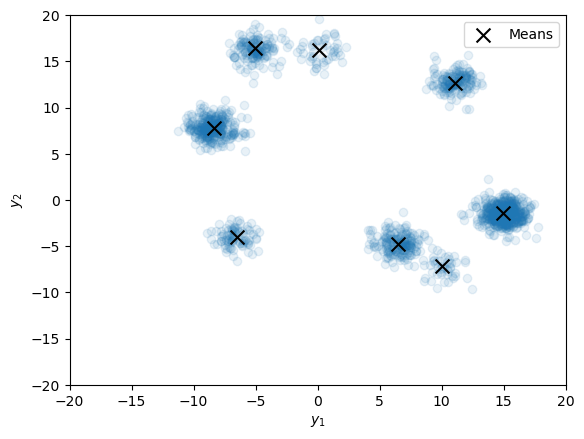

In [68]:
# Data generation from original paper
nr_samples = 1500
nr_clusters = 8
alpha = rand(50:300, nr_clusters)  # random integers between 50 and 300, with length nr_clusters
means = (rand(MersenneTwister(123), nr_clusters, 2).-0.5)*40
means_vec = [means[k,:] for k in 1:nr_clusters]
# to receive on average [0.1, 0.3, 0.2, 0.05, 0.15, 0.1, 0.05, 0.05], 
# multiply vector with alpha parameter (concentration). the higher alpha the closer the resulting draws from dirichlet to prior
# Dirichlet([100,300,200,50,150,100,50,50])
# Dirichlet(alpha)
probability_parameters = rand(MersenneTwister(123), Dirichlet([100,300,200,50,150,100,50,50]), 1);
dist = MixtureModel(
	map(m -> MvNormal(m, I), means_vec),
	Categorical(vec(probability_parameters)) # convert prop_par from matrix to vector for Categorical function
)
data = rand(MersenneTwister(123), dist, nr_samples);
plt.figure()
plt.scatter(data[1,:], data[2,:], alpha=0.1)
plt.scatter(means[:,1], means[:,2], color="black", marker="x", s=100, label="Means")
plt.xlabel(L"y_1")
plt.ylabel(L"y_2")
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.legend()
display(plt.gcf()) #gcf = get current figure

In [69]:
"""
image_to_tokens(img) -> Matrix{Float32} (N x 5)

Input:
- img::AbstractArray{<:Real,3} with size (H, W, 3), RGB in [0,1] or [0,255]

Output:
- tokens of size (N, 5) where each row is:
  [x_norm, y_norm, r, g, b]
  with x_norm, y_norm ∈ [-1, 1] (top-left = (-1,-1), bottom-right = (+1,+1)),
  and r, g, b ∈ [0,1].
- Pixels are ordered in Julia column-major order (iterate columns, then rows).
"""
function image_to_tokens(img::AbstractArray{<:Real,3})::Matrix{Float32}
	(size(img, 3) == 3) || throw(ArgumentError("img must have 3 channels in the last dimension (H×W×3)."))
	H, W, _ = size(img)
	N = H * W
	tokens = Matrix{Float32}(undef, N, 5)

	# Scale RGB to [0,1] if needed
	max_val = float(maximum(img))
	rgb_divisor::Float32 =
		(max_val <= 1.0f0) ? 1.0f0 :
		(max_val <= 255.0f0 ? 255.0f0 : Float32(max_val))

	# Map pixel index to [-1, 1], robust to singleton dims
	@inline normalize_index(k::Int, K::Int)::Float32 = K == 1 ? 0.0f0 : -1.0f0 + 2.0f0 * Float32(k - 1) / Float32(K - 1)

	n = 0
	@inbounds for j in 1:W
		x = normalize_index(j, W)
		for i in 1:H
			y = normalize_index(i, H)
			n += 1
			r = Float32(img[i, j, 1]) / rgb_divisor
			g = Float32(img[i, j, 2]) / rgb_divisor
			b = Float32(img[i, j, 3]) / rgb_divisor
			tokens[n, 1] = x
			tokens[n, 2] = y
			tokens[n, 3] = r
			tokens[n, 4] = g
			tokens[n, 5] = b
		end
	end

	return tokens
end

image_to_tokens

### Model specification


In [70]:
# Set upper bound number of components/clusters
nr_components = 8

8

In [71]:
I5 = I(5) # Creates a 5x5 identity matrix
O5x5 = zeros(5, 5) # Creates a 5x5 zero matrix
A = [I5 O5x5]
# O2x8 = zeros(2, 8) # Creates a 2x8 zero matrix
# I2 = I(2) # Creates a 2x2 identity matrix
# B = [O2x8 I2] # horizontally concatenate them
B = [O5x5 I5]

5×10 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0

In [72]:
I5 = I(5) # Creates a 5x5 identity matrix
O5x5 = zeros(5, 5) # Creates a 5x5 zero matrix
A = [I5 O5x5]
in = [1,1,100,150,150,30,20,0.01,0.02,0.5]
out= A*in

5-element Vector{Float64}:
   1.0
   1.0
 100.0
 150.0
 150.0

In [73]:
# @model function model_dirichlet_process(y,A, B, α, μ_θ, Λ_θ)
# 	local θk 
# 	#local w
	
#     # specify initial distribution over clusters
#     π ~ Dirichlet(α)
		
# 	# prior over model selection variable
# 	z ~ Categorical(π) where { 
# 		dependencies = EnforceMarginalFunctionalDependency(:out) 
# 	}
# 	# z ~ Categorical(π)

# 	# specify prior models over θ
# 	for k in 1:nr_components
# 		θk[k] ~ MvNormalMeanPrecision(μ_θ[k], Λ_θ[k])
# 	end

# 	# specify mixture distribution
# 	θ ~ Mixture(switch = z, inputs = θk) where { 
# 		# forces the node to depend on the switch marginal.
# 		dependencies = EnforceMarginalFunctionalDependency(:switch) 
# 	}

# 	# specify observation noise
# 	y ~ MvNormalMeanPrecision(θ, diagm(ones(5)))
# end

In [74]:
@model function model_dirichlet_process(y, A, B, α, μ_θ, Λ_θ, v_w, S_w)
    # `y` is specify experimental outcomes
    # `α`, `μ_θ` and `Λ_θ` are updatable parameters
	local θk 
	local w
	
    # specify initial distribution over clusters
    π ~ Dirichlet(α)
		
	# prior over model selection variable
	z ~ Categorical(π) where { 
		dependencies = EnforceMarginalFunctionalDependency(:out) 
	}

	# specify prior models over θ
	for k in 1:nr_components
		θk[k] ~ MvNormalMeanPrecision(μ_θ[k], Λ_θ[k])
		# specify prior over precision matrix
		# Wishart(degree of freedom (must be greater than or equal to the dimension of the scale matrix -> the higher the stronger is the prior)
		#                          , scale matrix (positive definite matrix))
		# w[k] ~ Wishart(6, 1e2*diagm(ones(5)))
		# w[k] ~ Wishart(6, diagm([1,1,100,100,100]))
		# S
		# w[k] ~ Wishart(v_w[k], [S1_w[k]   0    0 0 0;
		#                         0      S2_w[k] 0 0 0;
		# 						0         0    S3_w[k] 0 0;
		# 						0         0       0    S4_w[k] 0;
		# 						0         0       0       0    S5_w[k]])
		w[k] ~ Wishart(v_w[k], S_w[k])
	end

	y ~ NormalMixture(switch = z, m = θk, p = w) where { 
		# forces the node to depend on the switch marginal. This ensures the mixture only updates the selected component
		dependencies = EnforceMarginalFunctionalDependency(:switch) 
	}
end

### Constraint specification


In [75]:
@constraints function constraints_dirichlet_process()
    # For a categorical x, applying PointMassFormConstraint() collapses the posterior to the MAP category: the category with the highest probability.
    # Implementation-wise, for a proper Categorical distribution it returns PointMass(mode(d)) (i.e., a delta at the most probable category). 
    # Conceptually, this is equivalent to a one-hot vector with 1 at argmax(probvec(d)).
    q(z) :: PointMassFormConstraint()
    # MeanFieldFactorisation for NormalMixtureNode
    # q(switch, m, p) = q(switch)q(m)q(p)
    # Factorization around MixtureNode must be MeanField
    q(z, θk, w) = q(z)q(θk[1])q(w[1])q(θk[2])q(w[2])q(θk[3])q(w[3])q(θk[4])q(w[4])q(θk[5])q(w[5])q(θk[6])q(w[6])q(θk[7])q(w[7])q(θk[8])q(w[8])
    # q(z, π) = q(z)q(π)
    # q(z, θk) = q(z)q(θk[1])q(θk[2])q(θk[3])q(θk[4])q(θk[5])q(θk[6])q(θk[7])q(θk[8])

end;

In [76]:
# ohne meanfieldfactorization, mit klassicher factorization q(z,\pi): this is called with m_out (so in same cluster, it depends on message)
# mit meanfieldfactorization q(z)q(\pi) -> wird nicht gecallt. 
# rule print statement gibt wahrscheinlich nicht wieder ob marginal oder message verwendet wird zur berechnung, sondern ob es prinizipell auf marginal oder emessage beruht  
@rule Categorical(:p, Marginalisation) (m_out::Any,) = begin
	# println("Categorical - Backward update rule for π. m_out only")
	# println("Cat. node (backward), edge: m_out (marginal of z): ", m_out)
	@logscale -SpecialFunctions.logfactorial(length(params(m_out)[1]))
	# println("Cat. node, new π: ", params(m_out)[1] .+ one(eltype(params(m_out)[1])))
	return Dirichlet(params(m_out)[1] .+ one(eltype(params(m_out)[1])))
end

@rule Categorical(:p, Marginalisation) (q_out::Any,) = begin
	# println("Categorical - Backward update rule for π. q_out only")
	# println("Cat. node (backward), edge: q_out (marginal of z): ", q_out)
	@logscale -SpecialFunctions.logfactorial(length(params(q_out)[1]))
	# println("Cat. node, new π: ", params(q_out)[1] .+ one(eltype(params(q_out)[1])))
	return Dirichlet(params(q_out)[1] .+ one(eltype(params(q_out)[1])))
end

In [77]:
import Base.Broadcast: BroadcastFunction

@rule Categorical(:out, Marginalisation) (m_p::Dirichlet,) = begin
    # println("Cat. :out. with m_p::Dirichlet with alpha: ", params(m_p)[1])
    @logscale 0
    return Categorical(mean(m_p))
end

@rule Categorical(:out, Marginalisation) (q_p::Dirichlet,) = begin
    # println("Cat. :out. with q_p::Dirichlet with alpha: ", params(q_p)[1])
    @logscale 0
    rho = clamp.(exp.(mean(BroadcastFunction(log), q_p)), tiny, Inf) # Softens the parameter
    # println("   outgoing message is Categorical with: ", probvec(Categorical(rho ./ sum(rho))))
    return Categorical(rho ./ sum(rho))
end

### Probabilistic inference


In [78]:
# Set alpha from -5 to 5, default -1(replace with a slider if using Interact.jl)
alpha = log10(5) # log10(2) to obatin pi= 2 for new cluster.
# originally (zeros(2), 0.01*diagm(ones(2))); when A*θ then zeros(10), otherwise 5
# lower precision on 
# set mean in the middle of data (for x,y∈[-1,1] -> 0) (NEW for r,g,b∈[-1,1] -> 0 , before when scaled to [0,1] to 0.5
# precision of cluster mean should be at least 10, otherwise it influences the expected log-likelihood term calculation for the switch variable to much: \Sigma_µ + delta(y-µ)^2. since deltas max =4, when we have precision e.g. 1 -> Sigma_µ=1, makes the difference in delta less significant
base_measure = MvNormalMeanPrecision([0,0,0,0,0], 10*diagm([1, 1, 1, 1, 1]));

# Define 2 Auto-updates: update_alpha and broadcast_mean_precision
function update_alpha_vector(α_prev)
	#  Find index of first "inactive" cluster in α_prev
	ind = findfirst(x -> isapprox(1e-10,x;rtol=0.1), α_prev)
	# if all (predefined) components/clusters are active
	if isnothing(ind) 
		α_new = α_prev
		@error "upper bound reached (all given clusters(nr_components) were used at least once)"
	# case with only one active cluster (at least after 1st observation) 
	elseif ind == 2 && α_prev[1] != 10.0^alpha
		α_new = α_prev
		α_new[ind-1] = 1  # since we add +1 in backward update rule of pi from Categorical node (actually to all slots of alpha) we need to adjust/correct it to 1
		α_new[ind] = 10.0^alpha
	# case with more than one active cluster
	# make sure that ultimately activated cluster [ind-1] has α = 1 rather than α = 1+10.0^alpha (this value stems from the backward update rule of the categorical node for pi)
	elseif ind > 2 && α_prev[ind-1] ≈ 1+10.0^alpha
		α_new = α_prev
		α_new[ind-1] = 1 # same as in above case, reset it to 1
		α_new[ind] = 10.0^alpha
	else
		α_new = α_prev
	end
	# println("  and the new vector α_new: ", α_new)
	return α_new
end
function update_alpha(dist)
	# println("autoupdates for α with q(π) and its extracted probvec: ", dist)
	# println("extract underlying parameter vector of dirichlet dist using params(dist)[1]: ", params(dist)[1])
	return update_alpha_vector(params(dist)[1])
end

function broadcast_mean_precision(dists)
	# println("autoupdates for μ_θ, Λ_θ")
	# # println("autoupdates (broadcast_mean_precision) for μ_θ, Λ_θ")
	tmp = mean_precision.(dists) # for each distribution in dists print [mean, precision]
	return first.(tmp), last.(tmp) # first.(tmp) extracts all means from [mean, precision] vector for each distribution
end

function brodcast_degreeOfFreedom_scaleMatrix(dists) 
	# println("autoupdates for v_w, S_w")
	tmp = params.(dists)   # works for both Wishart and WishartFast
	return first.(tmp), last.(tmp)
end



# define update rules towards the inputs interface, when receiving a message from out (m_out) and marginal distribution from switch (q_switch).
# The m_out here is the message arriving at interface θ, dominated by the likelihood from y ~ MvNormalMeanPrecision(θ, ...).
@rule Mixture((:inputs, k), Marginalisation) (m_out::Any, q_switch::PointMass) = begin
	# println("-------------")
	# println("Mixture node, sending update to inputs (theta)")
	# This rule gets called for each k = 1, 2, 3, ..., N
    # where N is the number of components in the mixture
	
	# check whether mean is one-hot
	p = mean(q_switch) # Get the switch probabilities
	@assert sum(p) ≈ 1 "The selector variable connected to the Mixture node is not normalized."
	@assert all(x -> x == 1 || x == 0, p) "The selector variable connected to the Mixture node is not one-hot encoded."

	# get selected cluster
	kmax = argmax(p) # Find which component is active


	if k == kmax
        @logscale 0
        return m_out  # only the selected component is updated
    else
        @logscale missing
        return missing  # all other components get no update
    end
end

In [79]:
autoupdates_dirichlet_process = @autoupdates begin
    α = update_alpha(q(π))
	μ_θ, Λ_θ = broadcast_mean_precision(q(θk))
    v_w, S_w = brodcast_degreeOfFreedom_scaleMatrix(q(w)) 
end;

In [80]:
# Meta specification for the deterministic node diagm
delta_meta = @meta begin
    diagm() -> DeltaMeta(method = Linearization())
  end

Meta: 
  diagm() -> DeltaMeta{Linearization, Nothing}(Linearization(), nothing)


Editing @rules

In [81]:
@rule Dirichlet(:out, Marginalisation) (m_a::PointMass{<:AbstractVector},) = begin
    # println("Dirichlet forward - message. with m_a::PointMass (message of alpha)") 
    return Dirichlet(mean(m_a))
end

@rule Dirichlet(:out, Marginalisation) (q_a::PointMass{<:AbstractVector},) = begin
    # println("Dirichlet forward - marginal with q_a::PointMass") 
    return Dirichlet(mean(q_a))
end

In [82]:
import StaticArrays: SVector
using StatsFuns: softmax, softmax!, logsumexp
import ReactiveMP: multiply_messages 
using ExponentialFamily: WishartFast

@rule Mixture(:switch, Marginalisation) (m_out::Any, m_inputs::ManyOf{N, Any}) where {N} = begin
    # println("Mixture node, update switch. input m_out:", m_out, " theta m_inputs: ")
    # # println("messages[1]", messages[1]) # messages[1] equals m_out
    # # println("messages[2]", messages[2]) # messages[2] equals m_inputs
    #  compute logscales of different products
    # `messages` are available from the `@rule` macro itself
    # for each element in messages[2] = each component θk[k], multiply with current observation to obtain log evidence.
    # logscales returns the log-normalizer (=integral) of the product message equal to ∫ m_out(θ) m_k(θ) dθ for each component m_k[k]
    logscales = map(input -> getlogscale(multiply_messages(GenericProd(), messages[1], input)), messages[2])
    # println("Mixture node, output send to switch: ", probvec(Categorical(softmax(collect(logscales)))))

    # Definition: logsumexp(logscales) = log(∑_k exp(logscales[k])).
    # Type: one scalar, the log-normalizer (totoal log evidence of the factor)
    @logscale logsumexp(logscales)

    # softmax normalizes into a Categorical vector over components, summing to 1
    return Categorical(softmax(collect(logscales)))
end


@rule NormalMixture{N}(:switch, Marginalisation) (m_out::Any, m_m::ManyOf{N, Any}, m_p::ManyOf{N, Any}) where {N} = begin
    # println("rule NormalMixture{N}(:switch, Marginalisation) (m_out::Any, m_m::ManyOf{N, Any}, m_p::ManyOf{N, Any}) where {N}")
    # println("    m_out: ", m_out)
    # for each component k in the mixture, compute rule_nm_switch_k
    # rule_nm_switch_k → returns a log-likelihood–like score of how well that component explains q_out
    U = map(zip(m_m, m_p)) do (m, p)
        rule_nm_switch_k(variate_form(typeof(m)), m_out, m, p)
    end
    @logscale logsumexp(U)
    # Apply softmax! to turn log-likelihood–like scores of observation belonging to each component k (stored in U) into probabilities over components (= a Categorical vector over components, summing to 1)
    # clamp! ensures numerical stability (avoids exact 0 or 1).
    # println("   vector of scores: ", U)
    # println("   outgoing message without clamp! and softmax without !: ", probvec(Categorical(softmax(U))))
    ## println("   outgoing message without clamp!: ", probvec(Categorical(softmax!(U))))
    # return Categorical(clamp!(softmax!(U), tiny, one(eltype(U)) - tiny))
    return Categorical(clamp!(softmax(U), tiny, one(eltype(U)) - tiny))

end

function rule_nm_switch_k(::Type{Univariate}, m_out, m, p)
    return -score(AverageEnergy(), NormalMeanPrecision, Val{(:out, :μ, :τ)}(), map((q) -> Marginal(q, false, false, nothing), (m_out, m, p)), nothing)
end

function rule_nm_switch_k(::Type{Multivariate}, m_out, m, p)
    # # println("rule_nm_switch_k - Multivariate")
    # # println("Marginal(m_out, false, false, nothing): ", Marginal(m_out, false, false, nothing))
    # println("rule_nm_switch_k, m_out: ", m_out)
    # println("    || m: ", m)
    # println("    || p: ", p)
    # println("       mean(p): ", mean(p))
    # score function calls function generated with @average_energy macro in MvNormalMeanPrecision node file ReactiveMP.jl\src\nodes\predefined\mv_normal_mean_precision.jl
    # # println("    result: ", -score(AverageEnergy(), MvNormalMeanPrecision, Val{(:out, :μ, :Λ)}(), map((q) -> Marginal(q, false, false, nothing), (m_out, m, p)), nothing))
    return -score(AverageEnergy(), MvNormalMeanPrecision, Val{(:out, :μ, :Λ)}(), map((q) -> Marginal(q, false, false, nothing), (m_out, m, p)), nothing)
end

# NormalMixture Mean rule
# z_bar[k] * mean(m_p) makes sure only relevant cluster mean gets updated
@rule NormalMixture((:m, k), Marginalisation) (m_out::Any, q_switch::Union{Categorical, Bernoulli, PointMass{<:AbstractVector}}, m_p::Any) = begin
    # println("rule NormalMixture((:m, k), Marginalisation) (m_out::Any, q_switch::Union{Categorical, Bernoulli, PointMass{<:AbstractVector}}, m_p::Any)")
    pv    = probvec(q_switch)
    T     = eltype(pv)
    z_bar = clamp.(pv, tiny, one(T) - tiny)

    F = variate_form(typeof(m_out))
    # println("   z_bar: ", z_bar)
    # println("   m_out: ", m_out)
    # println("   typeof(m_out): ", typeof(m_out))
    # println("   variate_form(typeof(m_out)): ", variate_form(typeof(m_out)))
    # println("   message p (m_p): ", m_p)
    # println("   mean(m_p): ", mean(m_p))
    # println("   result: ", convert(promote_variate_type(F, NormalMeanPrecision), mean(m_out), z_bar[k] * mean(m_p)))
    
    @logscale 0
    return convert(promote_variate_type(F, NormalMeanPrecision), mean(m_out), z_bar[k] * mean(m_p))
end

# NormalMixture out rule
@rule NormalMixture{N}(:out, Marginalisation) (q_switch::Any, m_m::ManyOf{N, Any}, m_p::ManyOf{N, Any}) where {N} = begin
    # println("rule NormalMixture{N}(:out, Marginalisation) (q_switch::Any, m_m::ManyOf{N, Any}, m_p::ManyOf{N, Any}) where {N}")
    πs = probvec(q_switch)

    # Better to preinitialize
    m_p_m = mean.(m_p)
    m_m_m = mean.(m_m)

    W = mapreduce(x -> x[1] * x[2], +, zip(πs, m_p_m))
    ξ = mapreduce(x -> x[1] * x[2] * x[3], +, zip(πs, m_p_m, m_m_m))

    return convert(promote_variate_type(typeof(ξ), NormalWeightedMeanPrecision), ξ, W)
end

# Normal Mixture Precision
@rule NormalMixture((:p, k), Marginalisation) (m_out::Any, q_switch::Any, m_m::Any) = begin
    m_mean_k, v_mean_k = mean_cov(m_m)
    m_out, v_out       = mean_cov(m_out)
    z_bar              = probvec(q_switch)
    # println("@rule NormalMixture(:p, k)")
    # println("   m_out: ", m_out) # Float32[-1.0, -0.44, 0.0, 0.0, 0.0]
    # println("   m_m: ", m_m) # MvNormalMeanPrecision( μ: [0.0, 0.0, 0.0, 0.0, 0.0] Λ: [5000.0 0.0 0.0 0.0 0.0; 0.0 5000.0 0.0 0.0 0.0; 0.0 0.0 5000.0 0.0 0.0; 0.0 0.0 0.0 5000.0 0.0; 0.0 0.0 0.0 0.0 5000.0] )
    # # println("   variate_form(typeof(m_m)): ", typeof(m_m.collection))
    @logscale 0
    # strangely m_out is just a vector not a PointMass(type Multivariate) when updating the precisions. so we cant use variate_form, but only type_of 
    # return rule_nm_p_k(variate_form(typeof(m_out)), m_mean_k, v_mean_k, m_out, v_out, z_bar, k)
    
    return rule_nm_p_k(typeof(m_out), m_mean_k, v_mean_k, m_out, v_out, z_bar, k)

end

function rule_nm_p_k(::Type{Univariate}, m_mean_k, v_mean_k, m_out, v_out, z_bar, k)
    return GammaShapeRate(one(eltype(z_bar)) + z_bar[k] / 2, z_bar[k] * (v_out + v_mean_k + abs2(m_out - m_mean_k)) / 2)
end

function rule_nm_p_k(::Type{Multivariate}, m_mean_k, v_mean_k, m_out, v_out, z_bar, k)
    return WishartFast(one(eltype(z_bar)) + z_bar[k] + length(m_mean_k), z_bar[k] * (v_out + v_mean_k + (m_out - m_mean_k) * (m_out - m_mean_k)'))
end

# Attention: defining WishartFast actually uses v and invS (not ! S)
function rule_nm_p_k(::Type{Vector{Float32}}, m_mean_k, v_mean_k, m_out, v_out, z_bar, k)
    # println("   sending Wishart with mean: ", mean(WishartFast(one(eltype(z_bar)) + z_bar[k] + length(m_mean_k), z_bar[k] * (v_out + v_mean_k + (m_out - m_mean_k) * (m_out - m_mean_k)'))))
    # println("   with v = ", one(eltype(z_bar)) + z_bar[k] + length(m_mean_k), " and invS: ", z_bar[k] * (v_out + v_mean_k + (m_out - m_mean_k) * (m_out - m_mean_k)'))
    # println("   invS is calculated with: z_bar[k] =", z_bar[k], " * ([v_out=",v_out,"] + [v_mean_k=", v_mean_k,"+ (m_out - m_mean_k) * (m_out - m_mean_k)'=", (m_out - m_mean_k) * (m_out - m_mean_k)')
    return WishartFast(one(eltype(z_bar)) + z_bar[k] + length(m_mean_k), z_bar[k] * (v_out + v_mean_k + (m_out - m_mean_k) * (m_out - m_mean_k)'))
end


rule_nm_p_k (generic function with 3 methods)

In [83]:
import MatrixCorrectionTools: AbstractCorrectionStrategy, correction!
@rule typeof(*)(:in, Marginalisation) (m_out::MultivariateNormalDistributionsFamily, m_A::PointMass{<:AbstractMatrix}, meta::Union{<:AbstractCorrectionStrategy, Nothing}) = begin
    # println("* node :in, with m_out: ", m_out, "* node, m_A: ", m_A, "* node, meta: ", meta)
    A = mean(m_A)
    @logscale 0 # this rule actually depends on shape of matrix A, if matrix A is rectangular then pass 0, if squred then include the Jacobian term −log|det(A)|, in julia:  
    # ld, _ = logabsdet(A)           # log |det(A)|
    # @logscale -ld                  # Jacobian from change of variables
    ξ_out, W_out = weightedmean_precision(m_out)
    W = correction!(meta, A' * W_out * A)
    # println("* node, output for :in - backward m_θ", MvNormalWeightedMeanPrecision(A' * ξ_out, W))
    return MvNormalWeightedMeanPrecision(A' * ξ_out, W)
end

In [84]:
@rule MvNormalMeanPrecision(:μ, Marginalisation) (q_out::PointMass, q_Λ::PointMass) = begin
    # println("MvNormalMeanPrecision - Backward - Variational - Deterministic with q_out::PointMass and q_Λ::PointMass")
    # println("MvNormalMeanPrecision: Incoming obs marginal q_out", q_out)
    # println("sent as μ", MvNormalMeanPrecision(mean(q_out), mean(q_Λ)))
    return MvNormalMeanPrecision(mean(q_out), mean(q_Λ))
end

In [85]:
function BayesBase.compute_logscale(new_dist::WishartFast, left_dist::WishartFast, right_dist::WishartFast)
    # lp = getlogpartition(MeanParametersSpace(), WishartFast)
    # return lp(BayesBase.params(MeanParametersSpace(), new_dist)...) -
    #        lp(BayesBase.params(MeanParametersSpace(), left_dist)...) -
    #        lp(BayesBase.params(MeanParametersSpace(), right_dist)...)
    # TODO: fix this, for testing set to 0, since above code threw error: MethodError: no method matching (::ExponentialFamily.var"#262#263")(::Float64, ::Matrix{Float64})
    # # println("ATTENTION - TODO: ExponentialFamily.jl/src/distributions/wishart.jl:217 - compute_logscale - set to 0, since above code threw error")
    return 0.0
end

In [86]:
function run_dirichlet_process(data)
    alpha_start = 1e-10*ones(nr_components)
    alpha_start[1] = 10.0^alpha
    return infer(
       model          = model_dirichlet_process(A=A, B=B),
       data           = (y = [data[:,k] for k=1:size(data,2)], ),
       constraints    = constraints_dirichlet_process(),
       initialization = @initialization(begin 
           q(π) = Dirichlet(alpha_start; check_args=false) # need to specify only for initial autoupdates
           q(θk) = base_measure
           # Wishart will produce a mean output of v*scalematrix (e.g. Wishart(6, [0.1,0.1,0.1]) makes 0.6*I_3 matrix)
           # it determines the precision of the obs. with which the cluster mean gets updated 
           # so the higher, the stronger the update of the cluster mean
           # invS > v_prior*\Sigma_{\mu_k} + v_prior*(4=maximum_distance^2) 
           q(w) = Wishart(50, 1/5*diagm([1,1,1,1,1]))
           #q(w) = vague(Wishart, 5)   
       end),
       # autoupdates happen at very beginning of inference loop, so they "set" priors for parameters like v_w, S_w based on given initialization of q(w)
       autoupdates    = autoupdates_dirichlet_process,
       # meta = delta_meta,
       returnvars     = (:π, :θk, :w),
       keephistory    = size(data,2), # returns sample size = 1500
       historyvars    = (z = KeepLast(), π = KeepLast(), θk = KeepLast(), w = KeepLast()),
       autostart      = true,
       # addons         = (AddonMemory(), AddonLogScale())
       addons         = AddonLogScale()
   )
end;

### Results


In [96]:
results_dirichlet_process = run_dirichlet_process(data_img[:,:])
# results_dirichlet_process = run_dirichlet_process(data_img[:,6:12])

RxInferenceEngine:
  Posteriors stream    | enabled for (w, π, θk)
  Free Energy stream   | disabled
  Posteriors history   | available for (w, π, θk, z)
  Free Energy history  | unavailable
  Enabled events       | [  ]

In [88]:
#RxInfer.ReactiveMP.getaddons(results_dirichlet_process.posteriors[:z])

In [97]:
"""
    indices_per_cluster(z_mean_vectors::AbstractVector{<:AbstractVector{<:Real}}) -> Vector{Vector{Int}}

Given `z_mean_vectors` (length N, each entry a vector of length K with one-hot or probabilities),
return a vector of length K where the k-th element contains the indices of data points assigned to cluster k.
Assignment is by argmax (works for exact one-hot or soft assignments).
"""
function indices_per_cluster(z_mean_vectors::AbstractVector{<:AbstractVector{<:Real}})
    N = length(z_mean_vectors)
    N == 0 && return Vector{Vector{Int}}()
    K = length(z_mean_vectors[1])

    # Basic validation
    any(v -> length(v) != K, z_mean_vectors) && throw(ArgumentError("All z vectors must have the same length K"))
    K <= 0 && throw(ArgumentError("Number of clusters K must be positive"))

    members = [Int[] for _ in 1:K]
    for (i, p) in enumerate(z_mean_vectors)
        k = argmax(p)  # 1-based cluster index
        push!(members[k], i)
    end
    return members
end

"""
    indices_for_cluster(z_mean_vectors::AbstractVector{<:AbstractVector{<:Real}}, cluster_id::Integer) -> Vector{Int}

Return indices of data points assigned to a specific `cluster_id` (1-based).
"""
function indices_for_cluster(z_mean_vectors::AbstractVector{<:AbstractVector{<:Real}}, cluster_id::Integer)
    members = indices_per_cluster(z_mean_vectors)
    (cluster_id < 1 || cluster_id > length(members)) && throw(ArgumentError("cluster_id out of bounds"))
    return members[cluster_id]
end

indices_for_cluster

In [98]:
z_mean_vectors = mean.(results_dirichlet_process.history[:z][1:6])
all_members = indices_per_cluster(z_mean_vectors)      # Vector{Vector{Int}} of length K
# cluster3_idx = indices_for_cluster(z_mean_vectors, 3)  # indices for cluster 3

8-element Vector{Vector{Int64}}:
 [1, 2, 3, 4, 5, 6]
 []
 []
 []
 []
 []
 []
 []

In [99]:
# results_dirichlet_process.history[:θk][timestep][component k]
results_dirichlet_process.history[:θk][10][1]
#results_dirichlet_process.history[:π][676]
#mean.(results_dirichlet_process.history[:z][1:676])

Marginal(MvNormalWeightedMeanPrecision(
xi: [-47.69411627769604, -22.811605761801786, -47.6941162776737, -47.694116277673814, -47.694116277673736]
Λ: [93.60377618467845 -8.662140299774153 -10.127216755439012 -10.127216755439019 -10.12721675543902; -8.662140299774153 94.69618633279102 -8.662140299774142 -8.662140299774155 -8.66214029977415; -10.127216755439012 -8.662140299774142 93.60377618467844 -10.12721675543902 -10.127216755439004; -10.127216755439019 -8.662140299774155 -10.12721675543902 93.6037761846785 -10.127216755439008; -10.12721675543902 -8.66214029977415 -10.127216755439004 -10.127216755439008 93.60377618467842]
)
)) with (AddonLogScale{Float64}(-68.14187059405465),)

In [100]:
data_img[:,10]

5-element Vector{Float32}:
 -1.0
 -0.27999997
  1.0
  1.0
  1.0

In [101]:
# Set sample index N (1:nr_sample)(replace with a slider if using Interact.jl)
N = size(data_img, 2)

676

In [ ]:
mean(results_dirichlet_process.history[:θk][676][1])
params(results_dirichlet_process.history[:π][N])[1]
# println("hi")
v = params(results_dirichlet_process.history[:π][N])[1]
for i in eachindex(v)
    # println(":pi alpha count", v[i])
    # println("and its mean", mean(results_dirichlet_process.history[:θk][676][i]))
end


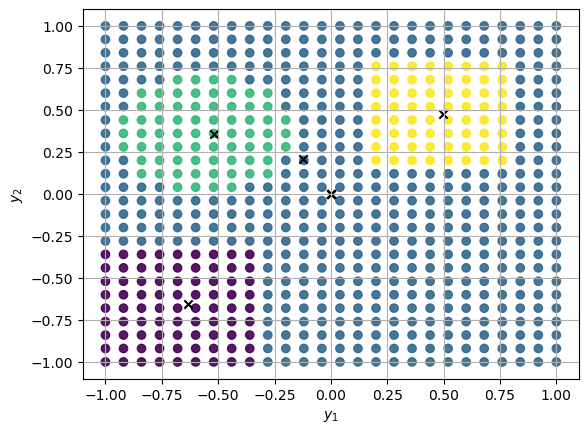

In [106]:
plt.figure()
plt.scatter(data_img[1,1:N], data_img[2,1:N], alpha=0.9, c=argmax.(mean.(results_dirichlet_process.history[:z][1:N])))
v = params(results_dirichlet_process.history[:π][N])[1]
for k in eachindex(v)
    plt.scatter(mean(results_dirichlet_process.history[:θk][N][k])[1], mean(results_dirichlet_process.history[:θk][N][k])[2], marker="x", color="black")
end
plt.xlabel(L"y_1")
plt.ylabel(L"y_2")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.grid()
plt.gcf()